#### Load Data

In [1]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates

import re

# yfinance  — free library to download stock price history
import yfinance as yf

# VADER    — sentiment analyser built for short financial/social media text
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# scipy    — for the Pearson correlation test
# from scipy import stats

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded.')

All libraries loaded.


---
## Step 1 — What is the Stock Market?

The stock market is a place where people **buy and sell small pieces of ownership** in companies.  
Each piece is called a **share** (also called a stock or equity).

Every publicly listed company has a short code called a **ticker symbol**:

| Company | Ticker |
|---------|--------|
| Apple | `AAPL` |
| Tesla | `TSLA` |
| Google (Alphabet) | `GOOGL` |
| Amazon | `AMZN` |
| Microsoft | `MSFT` |

With one line of Python code we can download years of daily price history for any of these companies.

In [2]:
headlines_raw = pd.read_csv('../Data/newsData/raw_analyst_ratings.csv')
headlines_raw.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
news_df = pd.DataFrame(headlines_raw, columns=['headline', 'publisher', 'date', 'stock'])
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

print(f'News dataset: {len(news_df)} headlines')
print(f'Tickers: {sorted(news_df["stock"].unique())}')
print(f'Date range: {news_df["date"].min().date()} to {news_df["date"].max().date()}')
print()
print('Sample rows:')
news_df.sample(5, random_state=1)[['headline', 'publisher', 'date', 'stock']]

News dataset: 1407328 headlines
Tickers: ['A', 'AA', 'AAC', 'AADR', 'AAL', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAU', 'AAV', 'AAVL', 'AAWW', 'AAXJ', 'AB', 'ABAC', 'ABAX', 'ABB', 'ABBV', 'ABC', 'ABCB', 'ABCD', 'ABCO', 'ABCW', 'ABDC', 'ABEV', 'ABG', 'ABGB', 'ABIO', 'ABM', 'ABMD', 'ABR', 'ABTL', 'ABX', 'ABY', 'ACAD', 'ACAS', 'ACAT', 'ACC', 'ACCO', 'ACCU', 'ACE', 'ACET', 'ACFC', 'ACFN', 'ACG', 'ACGL', 'ACH', 'ACHC', 'ACHN', 'ACIW', 'ACLS', 'ACM', 'ACMP', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACPW', 'ACRE', 'ACRX', 'ACSF', 'ACST', 'ACT', 'ACTA', 'ACTG', 'ACTS', 'ACU', 'ACUR', 'ACWI', 'ACWV', 'ACWX', 'ACXM', 'ACY', 'ADAT', 'ADBE', 'ADC', 'ADEP', 'ADES', 'ADGE', 'ADHD', 'ADI', 'ADK', 'ADM', 'ADMA', 'ADMP', 'ADMS', 'ADNC', 'ADP', 'ADPT', 'ADRA', 'ADRD', 'ADRE', 'ADRU', 'ADS', 'ADSK', 'ADT', 'ADTN', 'ADVS', 'ADX', 'ADXS', 'ADZ', 'AE', 'AEB', 'AEC', 'AEE', 'AEG', 'AEGN', 'AEGR', 'AEHR', 'AEIS', 'AEL', 'AEM', 'AEO', 'AEPI', 'AER', 'AERI', 'AES', 'AET', 'AETI', 'AEY', 'AEZS', 'AF', 'AFA

,headline,publisher,date,stock
1099349,"#PreMarket Primer: Wednesday, June 11: PBOC Lo...",Laura Brodbeck,2014-06-11 00:00:00+00:00,RSH
655417,"Shares of several technology, software, and se...",Benzinga Newsdesk,2020-03-12 00:00:00+00:00,IIVI
1048516,Morning Market Gainers,Lisa Levin,2015-01-30 00:00:00+00:00,QLGC
257481,Commercial Metals Reports Q1 Adj. EPS $0.32 vs...,Paul Quintaro,2018-01-03 00:00:00+00:00,CMC
621466,"The Russell 2000 Has Underwhelmed This Year, B...",Jim Swanson,2015-12-03 00:00:00+00:00,HOMB


In [4]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype              
---  ------     --------------    -----              
 0   headline   1407328 non-null  object             
 1   publisher  1407328 non-null  object             
 2   date       1407328 non-null  datetime64[ns, UTC]
 3   stock      1407328 non-null  object             
dtypes: datetime64[ns, UTC](1), object(3)
memory usage: 42.9+ MB


In [5]:
news_df['headline_len'] = news_df['headline'].str.len()

print('── Headline Character Count Statistics ──')
print(news_df['headline_len'].describe().round(1).to_string())

── Headline Character Count Statistics ──
count    1407328.0
mean          73.1
std           40.7
min            3.0
25%           47.0
50%           64.0
75%           87.0
max          512.0


In [6]:
# Count the number of headlines from each publisher
publisher_counts = news_df['publisher'].value_counts()

print(publisher_counts.head(20))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


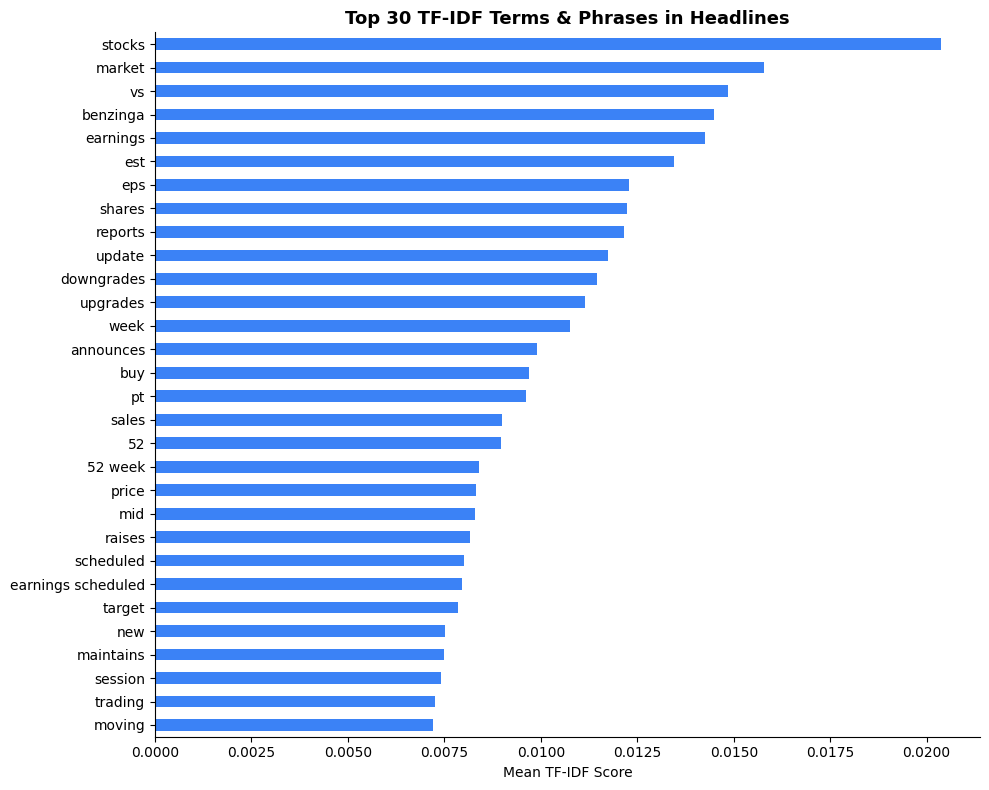

In [7]:
headlines = news_df['headline'].dropna().tolist()

# TF-IDF top keywords (unigrams + bigrams)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(headlines)

scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
terms  = np.array(tfidf.get_feature_names_out())
top_idx = scores.argsort()[-30:][::-1]
top_terms = pd.Series(scores[top_idx], index=terms[top_idx]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top_terms.plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_title('Top 30 TF-IDF Terms & Phrases in Headlines', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
# plt.savefig('outputs/fig4_tfidf_keywords.png', dpi=150)
plt.show()

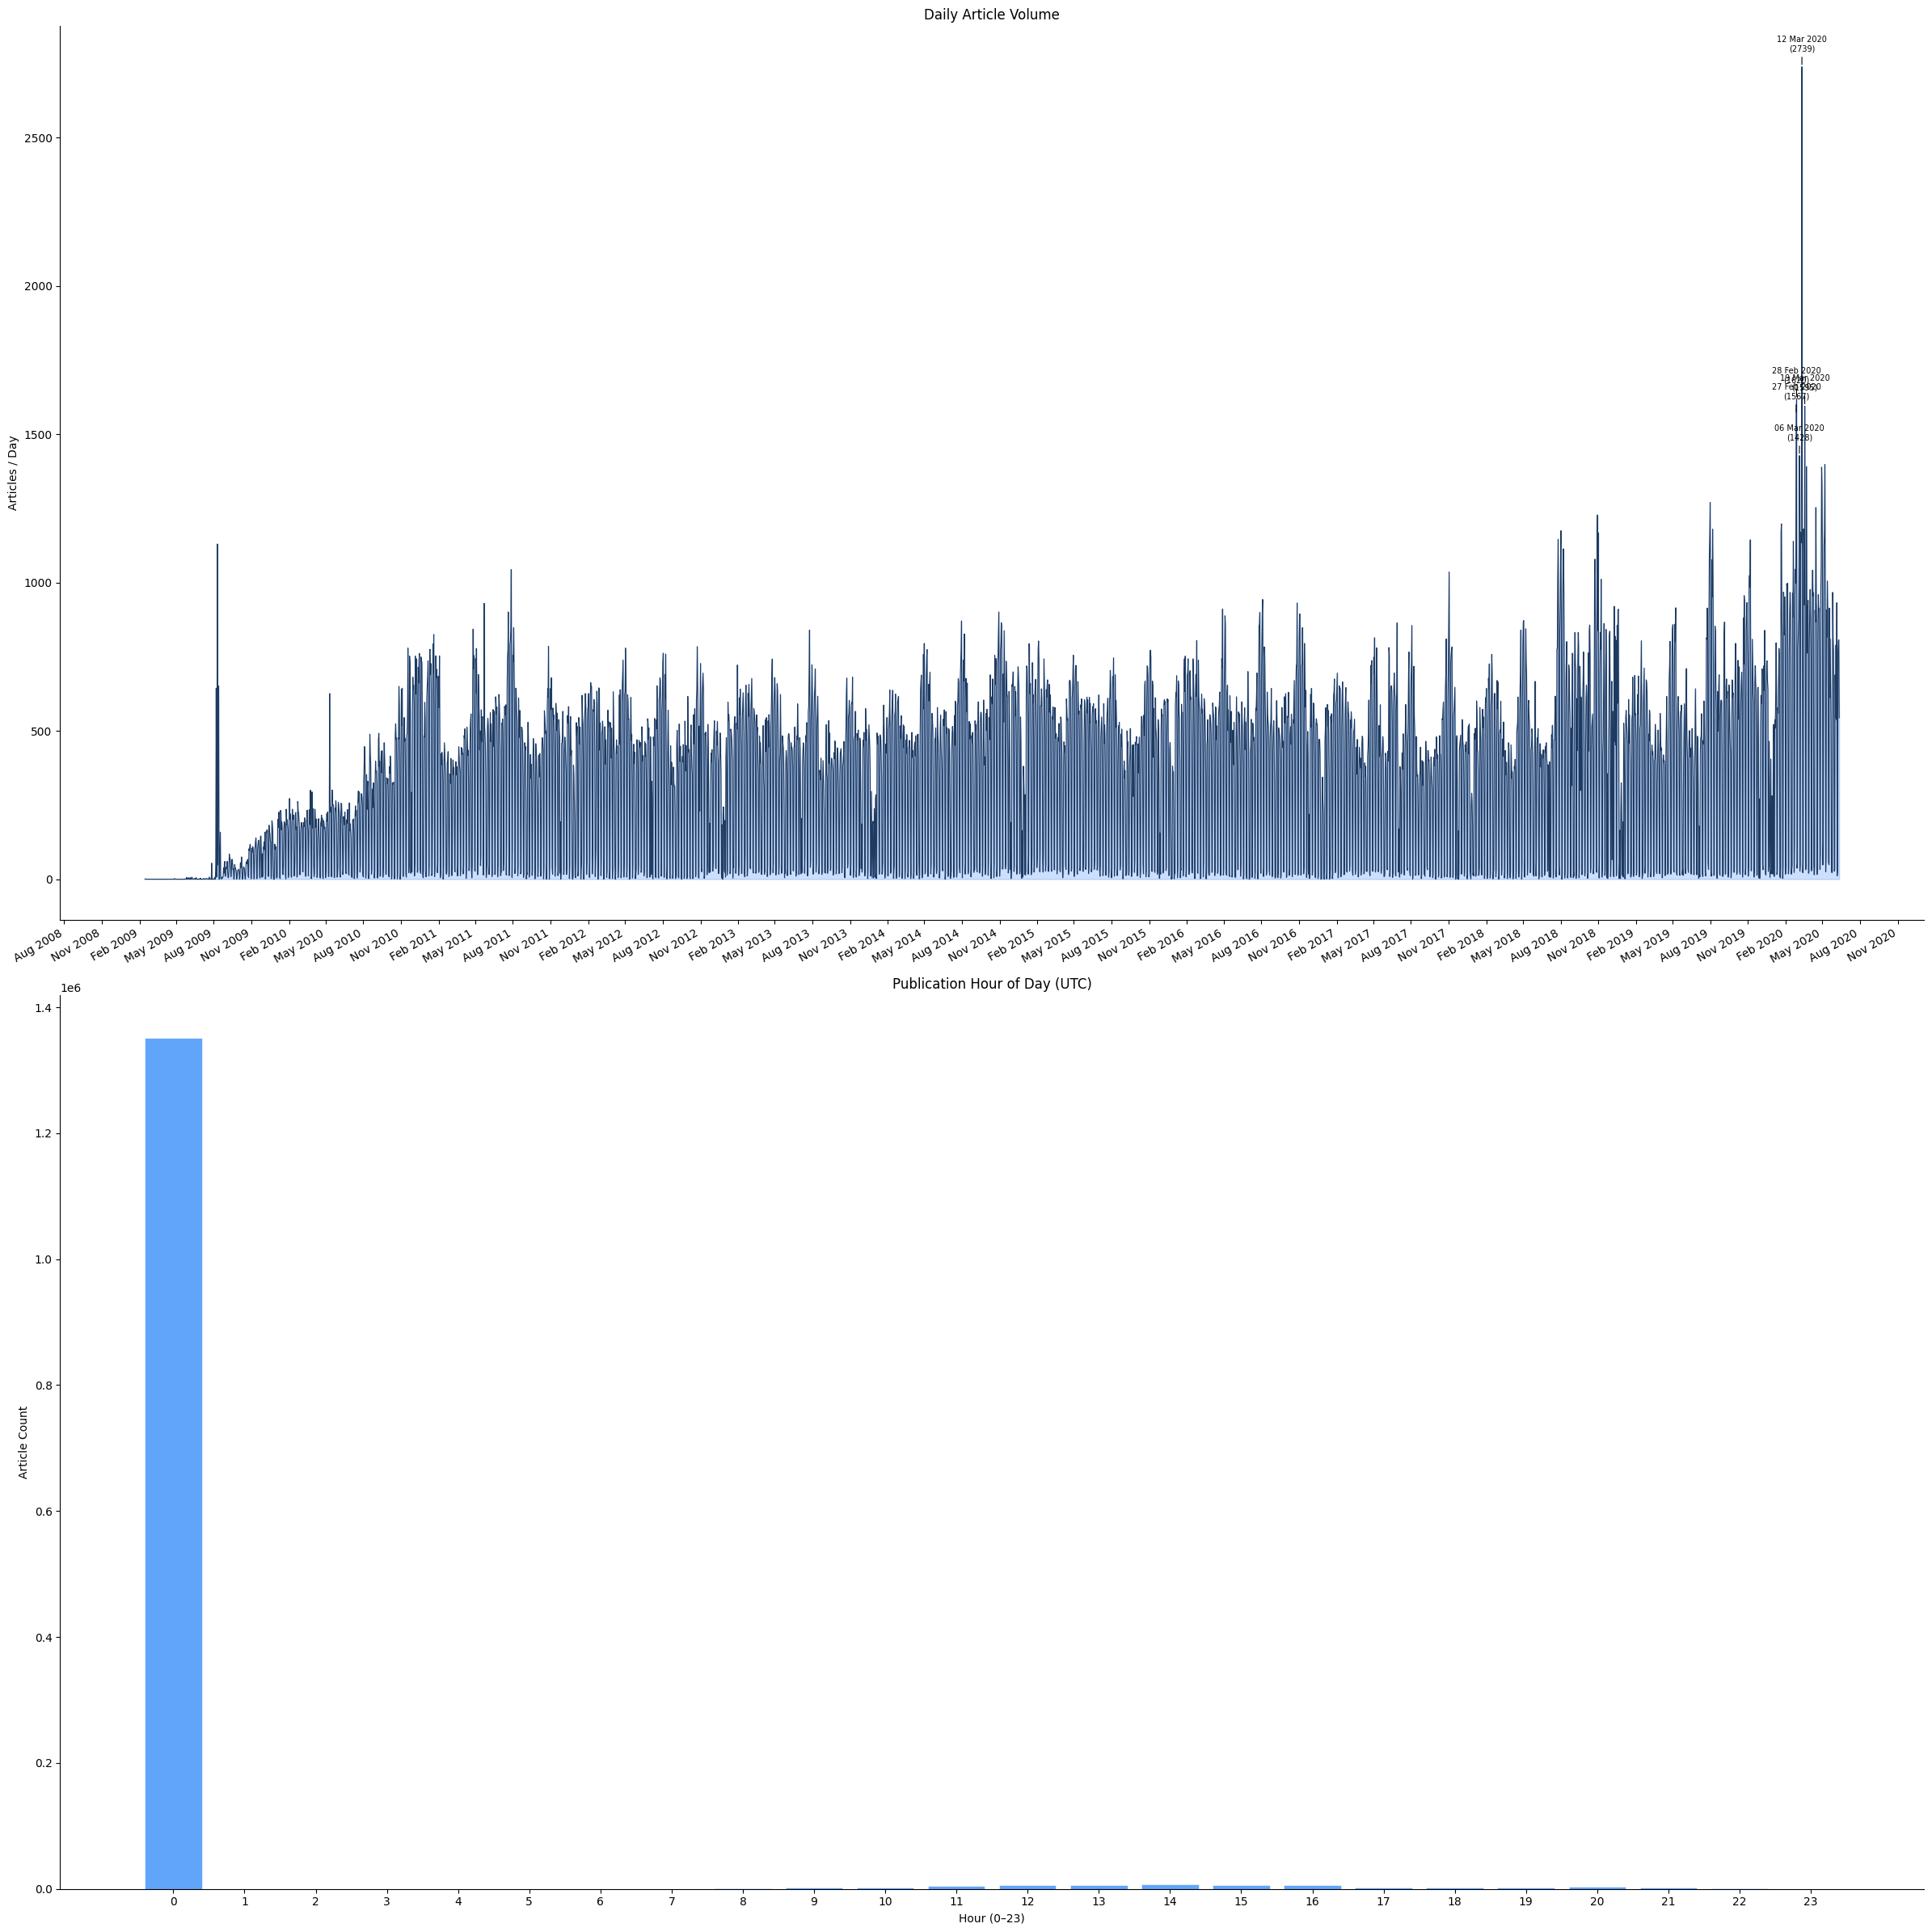

In [13]:
daily = news_df.set_index('date').resample('D').size().rename('articles')
monthly = news_df.set_index('date').resample('ME').size().rename('articles')

fig, axes = plt.subplots(2, 1, figsize=(24, 24))
# fig.suptitle('News Publication Time Series', fontsize=14, fontweight='bold')

# Daily volume
axes[0].plot(daily.index, daily.values, linewidth=0.8, color='#1e3a5f')
axes[0].fill_between(daily.index, daily.values, alpha=0.25, color='#3b82f6')
axes[0].set_title('Daily Article Volume')
axes[0].set_ylabel('Articles / Day')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Annotate top-5 spike days
top5 = daily.nlargest(5)
for dt, cnt in top5.items():
    axes[0].annotate(f'{dt.strftime("%d %b %Y")}\n({cnt})',
                     xy=(dt, cnt), xytext=(0, 14),
                     textcoords='offset points', ha='center', fontsize=7,
                     arrowprops=dict(arrowstyle='-', lw=0.8))

# Hour-of-day distribution
hourly = news_df['date'].dt.hour.value_counts().sort_index()
axes[1].bar(hourly.index, hourly.values, color='#60a5fa', edgecolor='white', linewidth=0.4)
axes[1].set_title('Publication Hour of Day (UTC)')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Article Count')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('outputs/fig3_time_series.png', dpi=150)
plt.show()

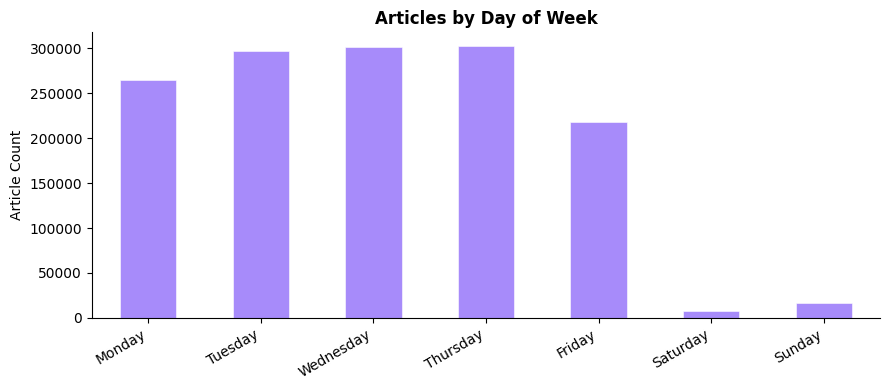

In [12]:
# Day-of-week pattern
news_df['day_of_week'] = news_df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = news_df['day_of_week'].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
dow_counts.plot(kind='bar', ax=ax, color='#a78bfa', edgecolor='white', linewidth=0.4)
ax.set_title('Articles by Day of Week', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Article Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

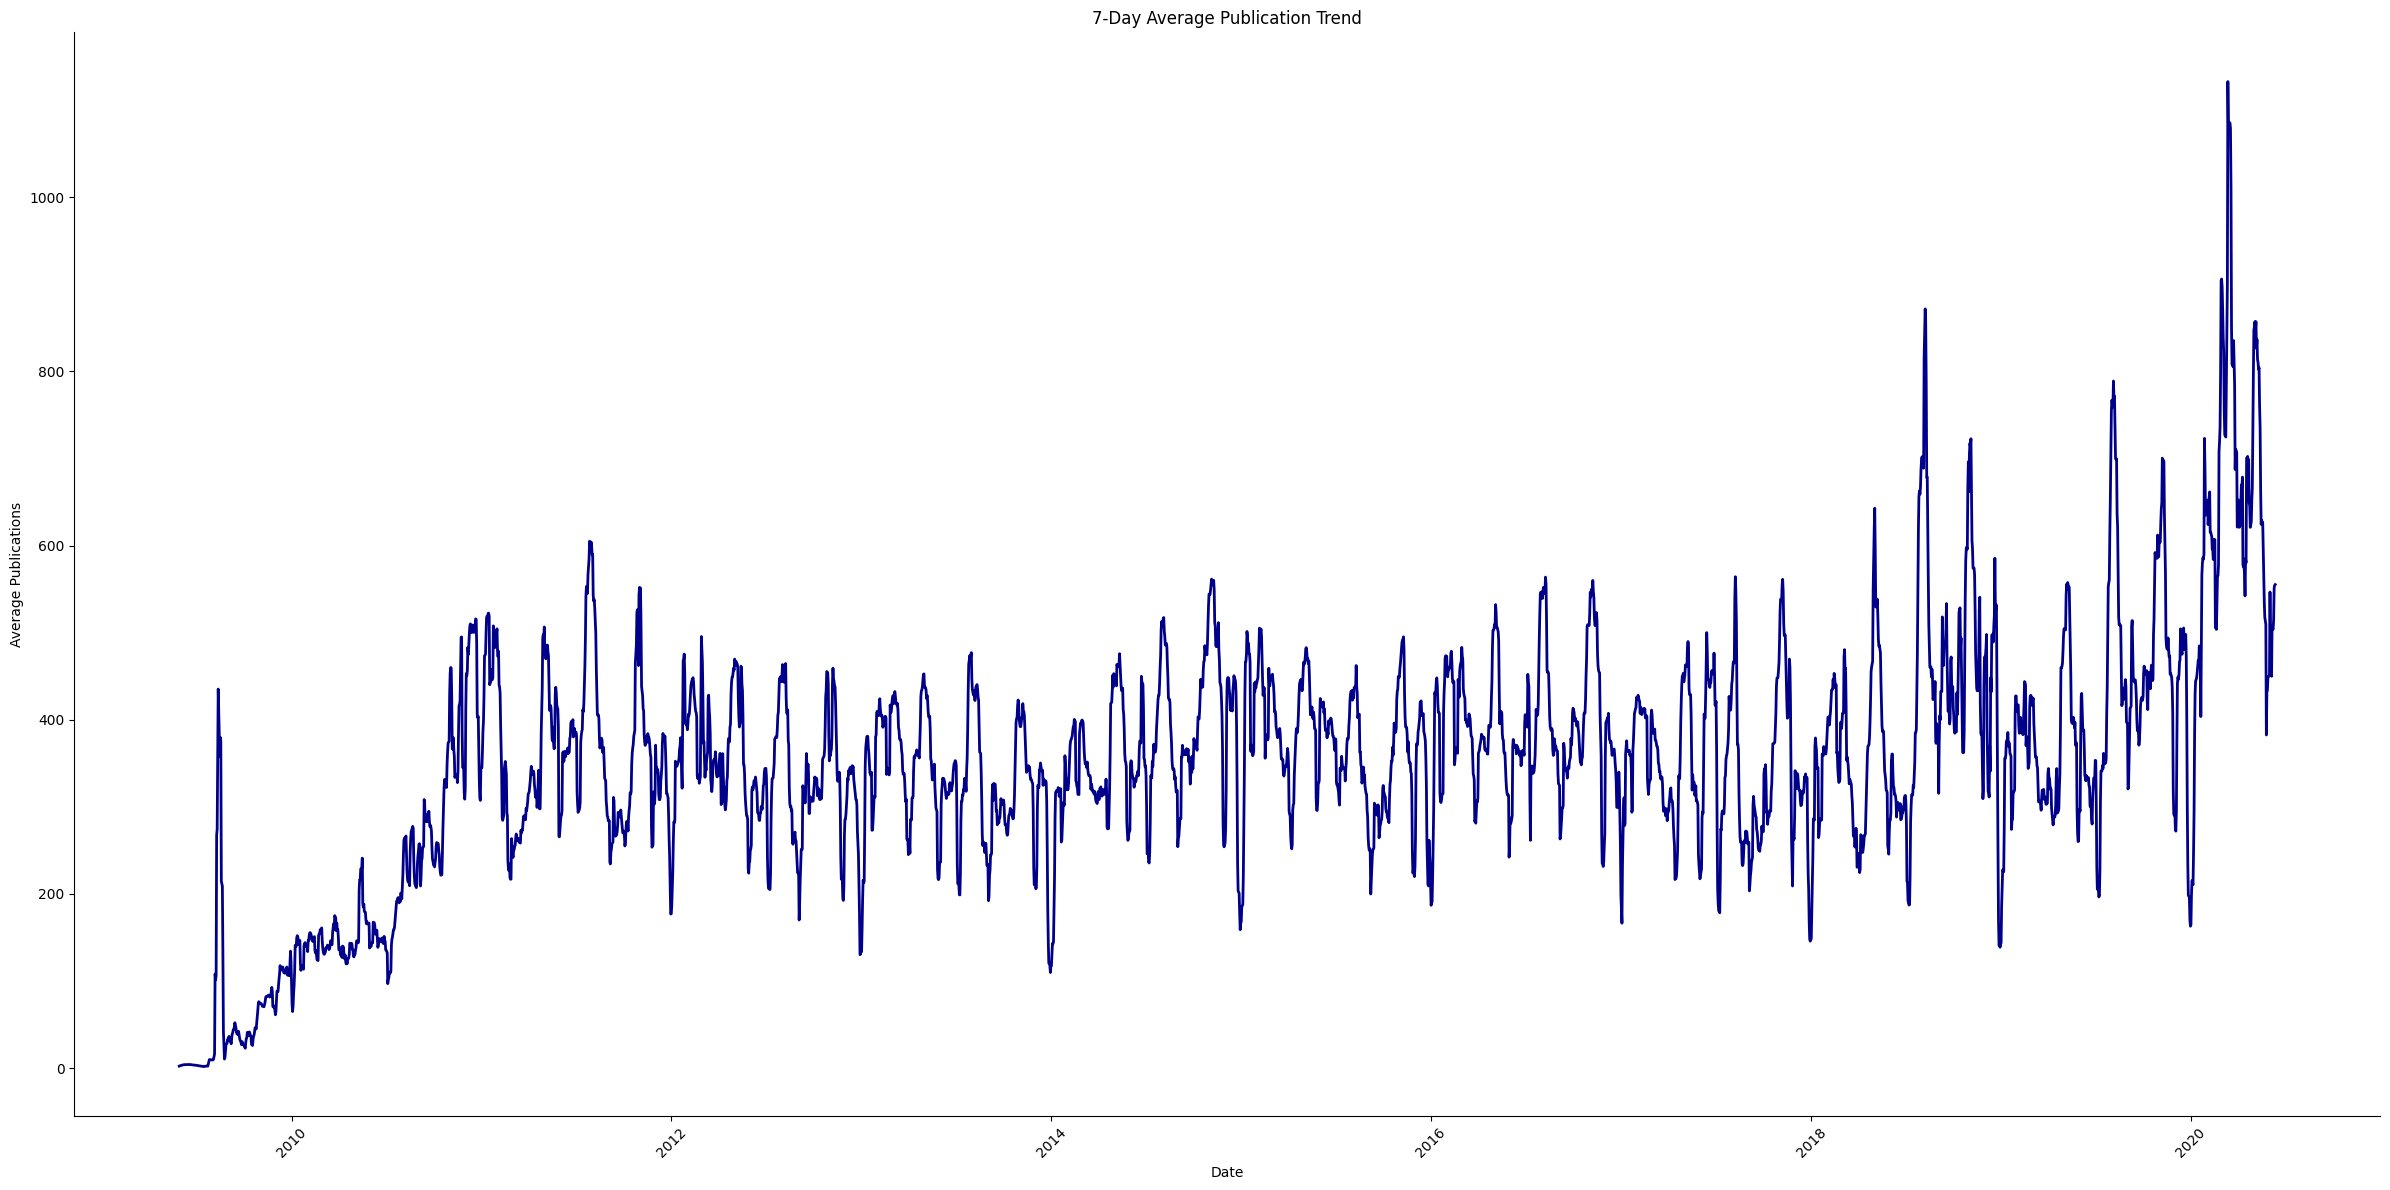

In [10]:
# Extract only the date
news_df['publication_date'] = news_df['date'].dt.date

# Count publications per day
publication_counts = (
    news_df.groupby('publication_date')
    .size()
)

rolling_avg = publication_counts.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(24, 12))

ax.plot(
    rolling_avg.index,
    rolling_avg.values,
    color='darkblue',
    linewidth=2
)

ax.set_title('7-Day Average Publication Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Average Publications')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()